<a href="https://colab.research.google.com/github/preranna-1/mindcall-health-intent-classifier/blob/main/Final_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
!pip install sentence-transformers -q
!pip install shap lime datasets scikit-learn matplotlib pandas -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [13]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import silhouette_score, adjusted_rand_score

from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from datasets import load_dataset
import shap
from lime.lime_text import LimeTextExplainer


In [14]:
# Load the datasets
train = pd.read_parquet("/content/drive/MyDrive/datamine/train-00000-of-00001.parquet")
validation = pd.read_parquet("/content/drive/MyDrive/datamine/validation-00000-of-00001.parquet")
test = pd.read_parquet("/content/drive/MyDrive/datamine/test-00000-of-00001.parquet")

# Display dataset sizes
print("Train Shape:", train.shape)
print("Validation Shape:", validation.shape)
print("Test Shape:", test.shape)

Train Shape: (3824, 8)
Validation Shape: (510, 8)
Test Shape: (765, 8)


In [15]:
train.head()

,patient_query,type,thinking,num_days,function,patient_id,assistant_response,text
0,I wonder if my inconsistent sleep is affecting...,implicit,User hints at connection between sleep and exe...,7.0,get_exercise_session_data,P_2578,<think>\nUser hints at connection between slee...,You are a helpful mental health assistant. Whe...
1,How’s my metabolism been since I started meds ...,explicit,The user explicitly asks about metabolism tied...,7.0,get_bmr_data,P_621,<think>\nThe user explicitly asks about metabo...,You are a helpful mental health assistant. Whe...
2,Can you check my blood glucose data for the la...,explicit,The user explicitly requests glucose data for ...,20.0,get_blood_glucose_data,P_3493,<think>\nThe user explicitly requests glucose ...,You are a helpful mental health assistant. Whe...
3,I solve problems faster in a chilly room—does ...,behavioral,Mild cold may enhance focus. Let's correlate y...,15.0,get_body_temp_data,P_1368,<think>\nMild cold may enhance focus. Let's co...,You are a helpful mental health assistant. Whe...
4,I took up daily runs two weeks ago. How far ha...,behavioral,"The user mentions a new habit of daily runs, i...",14.0,get_distance_data,P_881,<think>\nThe user mentions a new habit of dail...,You are a helpful mental health assistant. Whe...


In [16]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3824 entries, 0 to 3823
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patient_query       3824 non-null   object 
 1   type                3824 non-null   object 
 2   thinking            3824 non-null   object 
 3   num_days            3799 non-null   float64
 4   function            3824 non-null   object 
 5   patient_id          3824 non-null   object 
 6   assistant_response  3824 non-null   object 
 7   text                3824 non-null   object 
dtypes: float64(1), object(7)
memory usage: 239.1+ KB


*The training dataset contains 3,824 instances and 8 features. Seven features are categorical/textual (object type), while one feature (num_days) is numerical (float64). All columns are complete except num_days, which contains 25 missing values that will be handled during preprocessing.*

---

*EDA finding: The dataset consists of 3,824 training samples, 510 validation samples, and 765 test samples, with 8 features in each split. Dataset profiling was performed to examine the structure, data types, missing values, and duplicate records. The analysis showed that seven features are textual/categorical (object) and one feature (num_days) is numerical (float64). The num_days column contains 25 missing values, while all other features are complete. No duplicate records were found in the training dataset.*


---



In [17]:
# Check missing values
print("Missing Values:")
print(train.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", train.duplicated().sum())

Missing Values:
patient_query          0
type                   0
thinking               0
num_days              25
function               0
patient_id             0
assistant_response     0
text                   0
dtype: int64

Duplicate Rows: 0


In [18]:
print(train["function"].value_counts())

function
get_power_data                  208
get_bmr_data                    204
get_speed_data                  204
get_exercise_heart_rate_data    203
get_oxygen_saturation_data      202
get_steps_data                  202
get_height_data                 193
get_distance_data               192
get_blood_glucose_data          190
get_nutrition_data              189
get_blood_pressure_data         189
get_calories_burned_data        188
get_body_fat_data               186
get_heart_rate_data             186
get_stress_data                 183
get_exercise_session_data       182
get_body_temp_data              182
get_vo2max_data                 182
get_sleep_data                  181
get_weight_data                 178
Name: count, dtype: int64


Input X is: patient_query and Target Variable is : function. Why function and not type?

The type column has only three categories (implicit, explicit, behavioral), while function contains the actual action that should be performed. Predicting the function is a richer and more practical classification task, and your dataset appears to be designed for it.

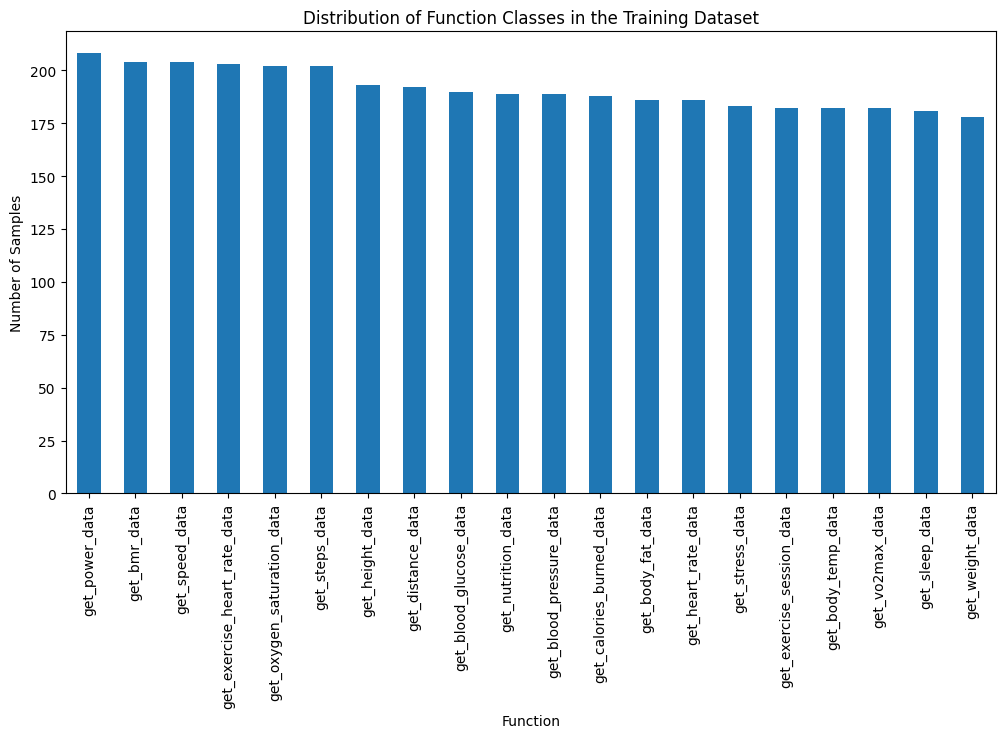

In [19]:
plt.figure(figsize=(12, 6))

train["function"].value_counts().plot(kind="bar")

plt.title("Distribution of Function Classes in the Training Dataset")
plt.xlabel("Function")
plt.ylabel("Number of Samples")
plt.xticks(rotation=90)

plt.show()

The bar chart shows the distribution of the target classes (function) in your training dataset.

Each bar represents one function (class), such as:
get_power_data
get_bmr_data
get_steps_data
get_sleep_data
etc.
The height of each bar represents the number of training samples belonging to that function.

For example:

get_power_data has 208 samples.
get_sleep_data has 181 samples.
get_weight_data has 178 samples.

The dataset is relatively balanced. ✅
Each class contains approximately 178–208 samples.
This is good because:

Every class has a similar number of examples.
The models won't be heavily biased toward one class.
Accuracy and F1-score will be more meaningful.

In [20]:
# Fill missing values in num_days using the median from the training set
median_days = train["num_days"].median()

train["num_days"] = train["num_days"].fillna(median_days)
validation["num_days"] = validation["num_days"].fillna(median_days)
test["num_days"] = test["num_days"].fillna(median_days)

In [21]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove punctuation
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [22]:
train["clean_query"] = train["patient_query"].apply(clean_text)
validation["clean_query"] = validation["patient_query"].apply(clean_text)
test["clean_query"] = test["patient_query"].apply(clean_text)

train[["patient_query", "clean_query"]].head()

,patient_query,clean_query
0,I wonder if my inconsistent sleep is affecting...,i wonder if my inconsistent sleep is affecting...
1,How’s my metabolism been since I started meds ...,hows my metabolism been since i started meds l...
2,Can you check my blood glucose data for the la...,can you check my blood glucose data for the la...
3,I solve problems faster in a chilly room—does ...,i solve problems faster in a chilly roomdoes m...
4,I took up daily runs two weeks ago. How far ha...,i took up daily runs two weeks ago how far hav...


Compared before and after cleaning / Data Preprocessing: Data Preprocessing:
The preprocessing stage involved handling missing values and cleaning the textual data. Missing values in the num_days feature were replaced using the median value computed from the training dataset. The patient_query text was converted to lowercase, URLs and punctuation were removed, and extra whitespace was eliminated to produce standardized text for TF-IDF feature extraction.

---



In [23]:
tfidf = TfidfVectorizer(max_features=5000)

# Convert text into TF-IDF features
X_train = tfidf.fit_transform(train["clean_query"])

X_validation = tfidf.transform(validation["clean_query"])

X_test = tfidf.transform(test["clean_query"])

# Labels
y_train = train["function"]
y_validation = validation["function"]
y_test = test["function"]

print("Training TF-IDF Shape:", X_train.shape)
print("Validation TF-IDF Shape:", X_validation.shape)
print("Test TF-IDF Shape:", X_test.shape)

Training TF-IDF Shape: (3824, 3596)
Validation TF-IDF Shape: (510, 3596)
Test TF-IDF Shape: (765, 3596)


TF-IDF Feature Extraction:

1.   List item
2.   List item

The cleaned patient queries were transformed into numerical feature vectors using the TF-IDF vectorization technique. Although the maximum vocabulary size was set to 5,000, the training dataset contained 3,596 unique informative terms, resulting in a TF-IDF feature matrix of size 3824 × 3596 for the training set. The same feature space was applied to the validation and test datasets to ensure consistency.


In [24]:


# Create Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [25]:
y_pred_lr = lr_model.predict(X_test)

In [26]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7856209150326797

Classification Report:

                              precision    recall  f1-score   support

      get_blood_glucose_data       0.86      0.76      0.81        33
     get_blood_pressure_data       0.88      0.82      0.85        34
                get_bmr_data       0.91      0.84      0.87        37
           get_body_fat_data       0.89      0.72      0.79        43
          get_body_temp_data       0.95      0.93      0.94        43
    get_calories_burned_data       0.49      0.51      0.50        43
           get_distance_data       0.84      0.74      0.79        43
get_exercise_heart_rate_data       0.88      0.90      0.89        31
   get_exercise_session_data       0.56      0.53      0.54        36
         get_heart_rate_data       0.95      0.90      0.93        41
             get_height_data       0.88      0.82      0.85        34
          get_nutrition_data       0.71      0.83      0.77        42
  get_oxygen_saturation_data       

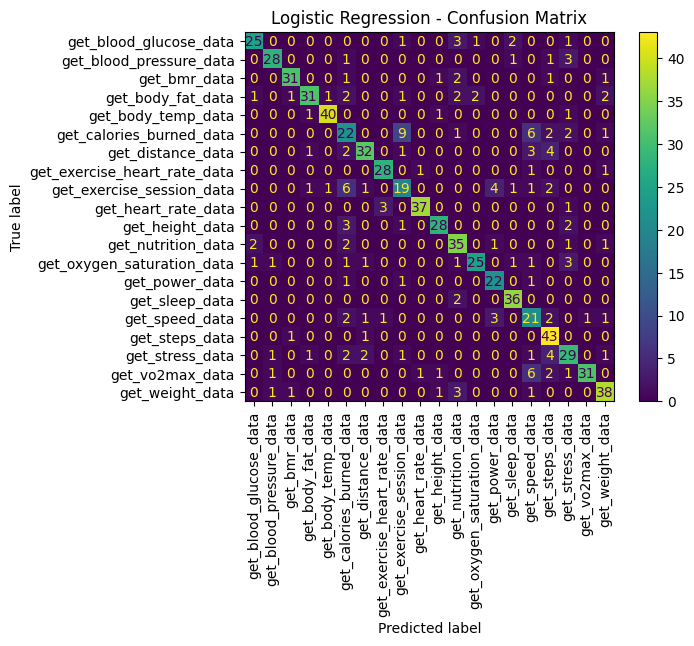

In [27]:
ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_test,
    y_test,
    xticks_rotation=90
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

Why are we evaluating on the test set?
Training set: Used to learn the model parameters.
Validation set: Typically used for tuning hyperparameters (e.g., choosing the best C value or model settings).
Test set: Used once at the end to measure how well the final model generalizes to unseen data.

For a baseline experiment, training on the training set and reporting results on the test set is appropriate.

In [28]:
svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

In [29]:

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.7986928104575164

Classification Report:

                              precision    recall  f1-score   support

      get_blood_glucose_data       0.90      0.79      0.84        33
     get_blood_pressure_data       0.85      0.85      0.85        34
                get_bmr_data       0.94      0.84      0.89        37
           get_body_fat_data       0.81      0.70      0.75        43
          get_body_temp_data       0.91      0.98      0.94        43
    get_calories_burned_data       0.57      0.60      0.58        43
           get_distance_data       0.82      0.77      0.80        43
get_exercise_heart_rate_data       0.80      0.90      0.85        31
   get_exercise_session_data       0.44      0.39      0.41        36
         get_heart_rate_data       0.97      0.85      0.91        41
             get_height_data       0.91      0.91      0.91        34
          get_nutrition_data       0.79      0.88      0.83        42
  get_oxygen_saturation_data       

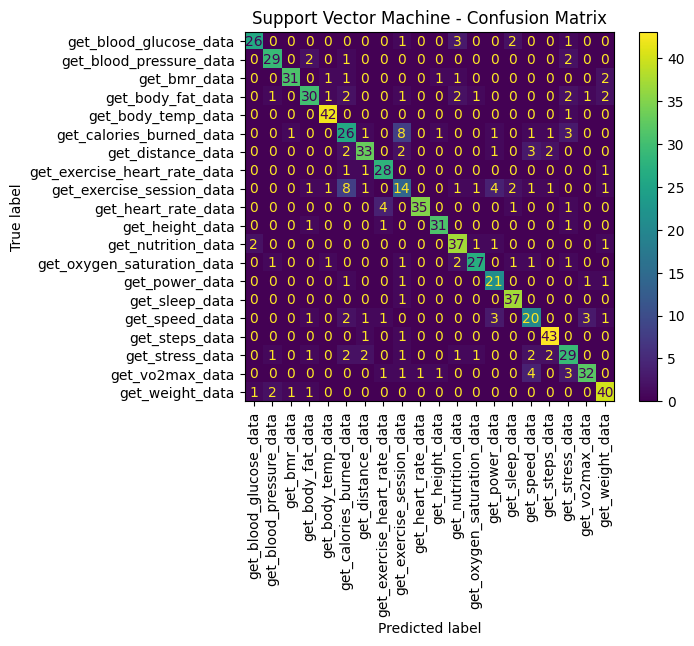

In [30]:


ConfusionMatrixDisplay.from_estimator(
    svm_model,
    X_test,
    y_test,
    xticks_rotation=90
)

plt.title("Support Vector Machine - Confusion Matrix")
plt.show()

In [31]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7725490196078432

Classification Report:

                              precision    recall  f1-score   support

      get_blood_glucose_data       0.83      0.76      0.79        33
     get_blood_pressure_data       0.87      0.79      0.83        34
                get_bmr_data       0.88      0.78      0.83        37
           get_body_fat_data       0.84      0.74      0.79        43
          get_body_temp_data       0.95      0.88      0.92        43
    get_calories_burned_data       0.47      0.53      0.50        43
           get_distance_data       0.78      0.72      0.75        43
get_exercise_heart_rate_data       0.87      0.87      0.87        31
   get_exercise_session_data       0.62      0.69      0.66        36
         get_heart_rate_data       0.88      0.88      0.88        41
             get_height_data       0.88      0.82      0.85        34
          get_nutrition_data       0.76      0.67      0.71        42
  get_oxygen_saturation_data       

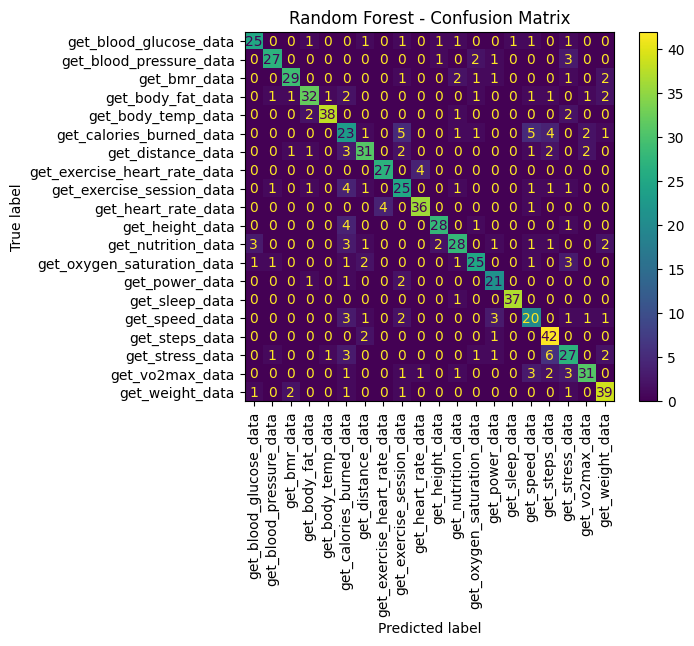

In [32]:
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    xticks_rotation=90
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

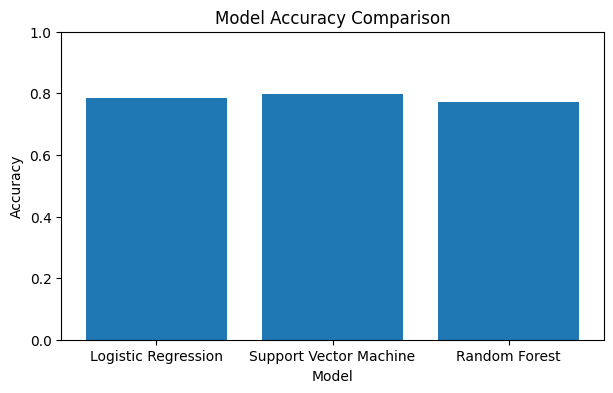

In [33]:

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Support Vector Machine",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results


plt.figure(figsize=(7,4))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

SVM achieved the highest accuracy (79.87%), making it the best-performing baseline model.
Logistic Regression performed almost as well, showing that linear models are effective for TF-IDF text features.
Random Forest achieved the lowest accuracy. This is common in text classification because tree-based models generally do not perform as well as linear models on high-dimensional sparse TF-IDF vectors.

In [34]:


def evaluate_model(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average='weighted'
    )

    accuracy = accuracy_score(y_true, y_pred)

    return accuracy, precision, recall, f1


lr_metrics = evaluate_model(y_test, y_pred_lr)
svm_metrics = evaluate_model(y_test, y_pred_svm)
rf_metrics = evaluate_model(y_test, y_pred_rf)

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Support Vector Machine",
        "Random Forest"
    ],
    "Accuracy": [lr_metrics[0], svm_metrics[0], rf_metrics[0]],
    "Precision": [lr_metrics[1], svm_metrics[1], rf_metrics[1]],
    "Recall": [lr_metrics[2], svm_metrics[2], rf_metrics[2]],
    "F1-score": [lr_metrics[3], svm_metrics[3], rf_metrics[3]]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.785621,0.799055,0.785621,0.787730
1,Support Vector Machine,0.798693,0.801224,0.798693,0.797668
2,Random Forest,0.772549,0.781195,0.772549,0.774405


In [35]:


model = SentenceTransformer('all-MiniLM-L6-v2')

X_train_emb = model.encode(train["clean_query"].tolist(), show_progress_bar=True)

print("Embedding shape:", X_train_emb.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/120 [00:00<?, ?it/s]

Embedding shape: (3824, 384)


In [36]:
n_clusters = train["function"].nunique()  # matches number of true classes, for comparison
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_train_emb)

train["kmeans_cluster"] = kmeans_labels


hier = AgglomerativeClustering(n_clusters=n_clusters)
hier_labels = hier.fit_predict(X_train_emb)

train["hier_cluster"] = hier_labels

dbscan = DBSCAN(eps=0.5, min_samples=5, metric='cosine')
dbscan_labels = dbscan.fit_predict(X_train_emb)

train["dbscan_cluster"] = dbscan_labels
print("Number of clusters found:", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
print("Noise points:", (dbscan_labels == -1).sum())

Number of clusters found: 1
Noise points: 64


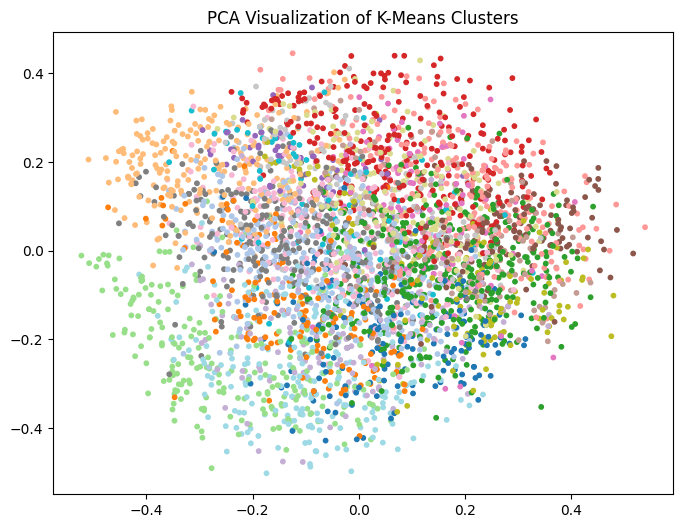

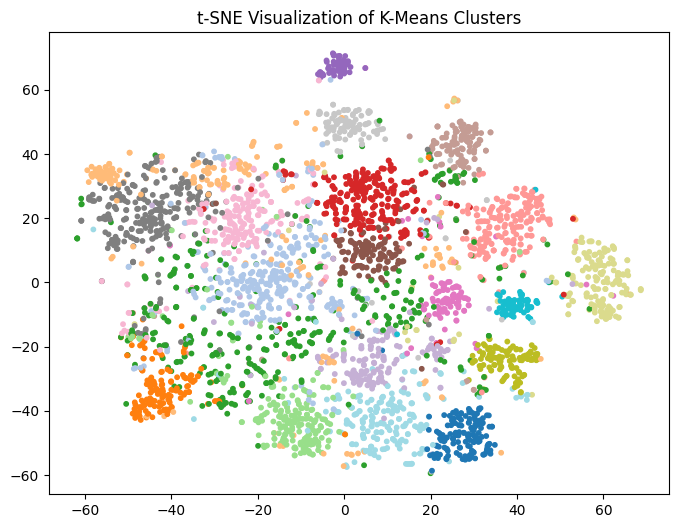

Silhouette Score - KMeans: 0.062447872
Silhouette Score - Hierarchical: 0.036156688
Adjusted Rand Index (KMeans vs true labels): 0.36984388125930256
Adjusted Rand Index (Hierarchical vs true labels): 0.2697663169381825


In [37]:


# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_emb)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels, cmap='tab20', s=10)
plt.title("PCA Visualization of K-Means Clusters")
plt.show()

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_train_emb)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=kmeans_labels, cmap='tab20', s=10)
plt.title("t-SNE Visualization of K-Means Clusters")
plt.show()



# Internal quality (doesn't need true labels)
sil_kmeans = silhouette_score(X_train_emb, kmeans_labels)
sil_hier = silhouette_score(X_train_emb, hier_labels)

print("Silhouette Score - KMeans:", sil_kmeans)
print("Silhouette Score - Hierarchical:", sil_hier)

# Comparison against real function labels (just to sanity-check your clusters)
ari_kmeans = adjusted_rand_score(train["function"], kmeans_labels)
ari_hier = adjusted_rand_score(train["function"], hier_labels)

print("Adjusted Rand Index (KMeans vs true labels):", ari_kmeans)
print("Adjusted Rand Index (Hierarchical vs true labels):", ari_hier)

# Data Mining Course Project

## Knowledge Discovery and Explainable AI

**Project:** Mental Health Function Prediction Using the MindCall Dataset

**Dataset:** MindCall Dataset (Hugging Face)  
https://huggingface.co/datasets/frshafi/mind_call

**Contributor:** Person 4 – Knowledge Discovery & Explainability

### Objectives

This notebook extends the baseline text classification models developed in the project by focusing on knowledge discovery and model interpretability. The implementation includes:

- Data loading and preprocessing
- TF-IDF feature representation
- Logistic Regression classifier (baseline reproduction)
- Association Rule Mining using FP-Growth
- Discovery of frequent itemsets and association rules
- Explainable AI using SHAP
- Local model interpretation using LIME
- Interpretation of discovered knowledge

The objective is to complement the predictive models with interpretable insights that improve transparency and support a better understanding of the model's decisions.

Data Mining Course Project
Person 4: Knowledge Discovery & Explainable AI

Dataset:
MindCall
https://huggingface.co/datasets/frshafi/mind_call

This notebook implements:
1. Dataset loading
2. Text preprocessing
3. TF-IDF feature extraction
4. Logistic Regression baseline
5. Association Rule Mining (FP-Growth)
6. SHAP Explainability
7. LIME Explainability

Author: Nawfa Nawar


In [38]:
explainer = shap.Explainer(
    lr_model,
    X_train,
    feature_names=tfidf.get_feature_names_out()
)

In [39]:
sample = X_test[:100]

shap_values = explainer(sample)

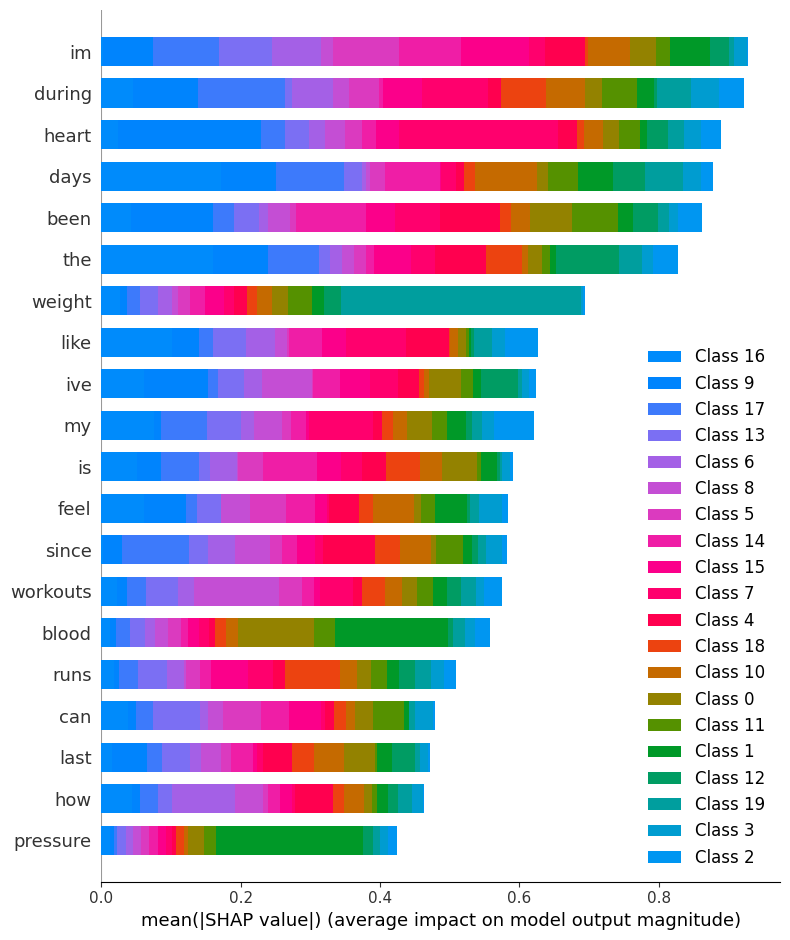

In [40]:
shap.summary_plot(
    shap_values,
    sample,
    feature_names=tfidf.get_feature_names_out()
)

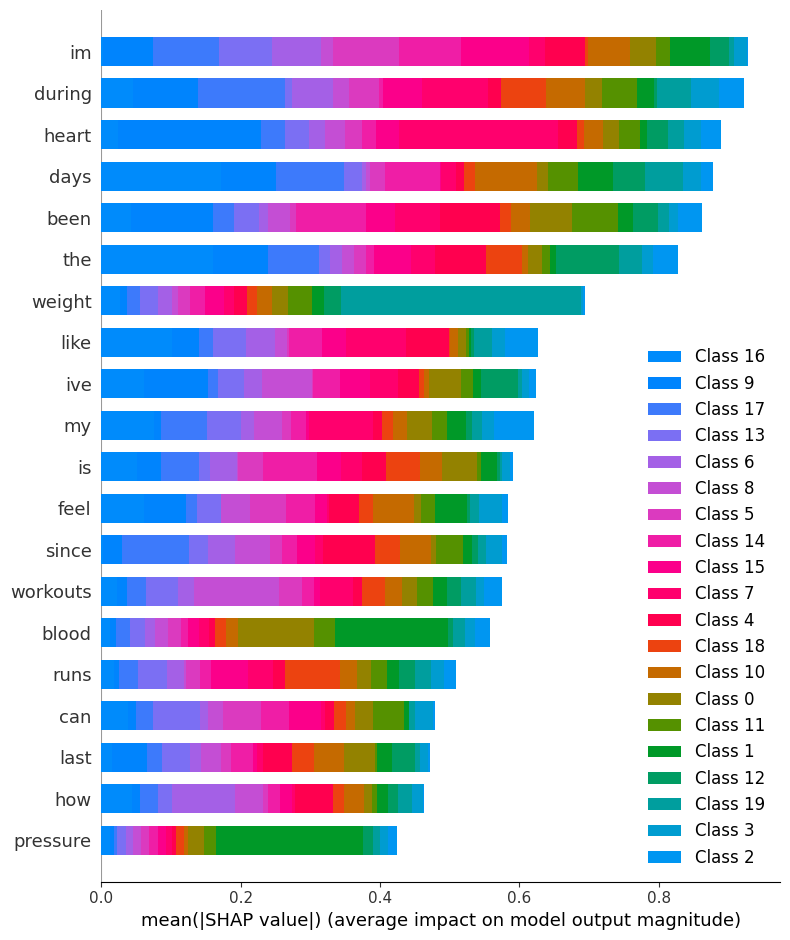

In [41]:
shap.summary_plot(
    shap_values,
    sample,
    feature_names=tfidf.get_feature_names_out(),
    plot_type="bar"
)

In [42]:
class_names = sorted(train["function"].unique())

explainer = LimeTextExplainer(
    class_names=class_names
)

In [43]:
def predict_proba(texts):
    cleaned = [clean_text(t) for t in texts]
    X = tfidf.transform(cleaned)
    return lr_model.predict_proba(X)

In [44]:
query = test["patient_query"].iloc[0]

print(query)

Since my therapist suggested 'sleep restriction' for insomnia, I'm exhausted but sleeping deeper. Is this the expected pattern?


In [45]:
exp = explainer.explain_instance(
    query,
    predict_proba,
    num_features=10,
    num_samples=500
)

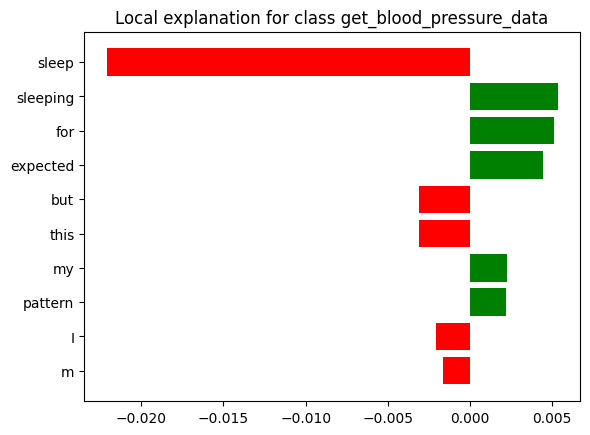

In [46]:
exp.as_list()

fig = exp.as_pyplot_figure()

plt.show()

In [47]:
prediction = lr_model.predict(
    tfidf.transform([clean_text(query)])
)

print(prediction)

['get_sleep_data']


In [48]:
predict_proba([query])

array([[0.03246764, 0.02516113, 0.02542389, 0.02336321, 0.02300961,
        0.03565843, 0.0298485 , 0.00825959, 0.03654727, 0.03365418,
        0.0385029 , 0.03713199, 0.03290341, 0.02844173, 0.4725706 ,
        0.03217169, 0.02628651, 0.01448022, 0.0259802 , 0.01813731]])

In [49]:
for i in [0, 10, 20]:
    query = test["patient_query"].iloc[i]

    exp = explainer.explain_instance(
        query,
        predict_proba,
        num_features=10,
        num_samples=500
    )

    print(f"\nQuery {i}:")
    print(query)
    print(exp.as_list())


Query 0:
Since my therapist suggested 'sleep restriction' for insomnia, I'm exhausted but sleeping deeper. Is this the expected pattern?
[(np.str_('sleep'), -0.021326122902847376), (np.str_('expected'), 0.0055786126680692945), (np.str_('for'), 0.004615273207567951), (np.str_('sleeping'), 0.004359092876241924), (np.str_('but'), -0.0036342964492228603), (np.str_('this'), -0.002691056381955797), (np.str_('I'), -0.0021556002827677143), (np.str_('m'), -0.002077842336590793), (np.str_('suggested'), 0.0017976352283150649), (np.str_('pattern'), 0.001694009708392997)]

Query 10:
My heart is a lullaby during knitting but a rock anthem during gaming.
[(np.str_('heart'), -0.018568705294093157), (np.str_('during'), -0.011429469631003351), (np.str_('rock'), 0.006553679124617754), (np.str_('is'), 0.002249112102051068), (np.str_('but'), -0.0014848507431164206), (np.str_('lullaby'), 0.001176566156067535), (np.str_('My'), 0.0010171021907760967), (np.str_('a'), -0.0010013177042100428), (np.str_('knittin

In [50]:
query = test["patient_query"].iloc[20]

print(query)

prediction = lr_model.predict(
    tfidf.transform([clean_text(query)])
)

print("Predicted class:", prediction[0])

Can you check my blood pressure trends for the last 18 days?
Predicted class: get_blood_pressure_data
